In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# load saved model checkpoint with metadata
model_path = "/content/drive/MyDrive/INTERNSHIP/best_cnn_model.pth"

checkpoint = torch.load(model_path, map_location=device)

class_names = checkpoint["class_names"]

print("number of classes:", len(class_names))

number of classes: 38


In [5]:
# define cnn model architecture
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64*56*56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
# load model weights
model = CNN(len(class_names)).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("model loaded successfully!")

model loaded successfully!


In [7]:
# define inference transforms
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

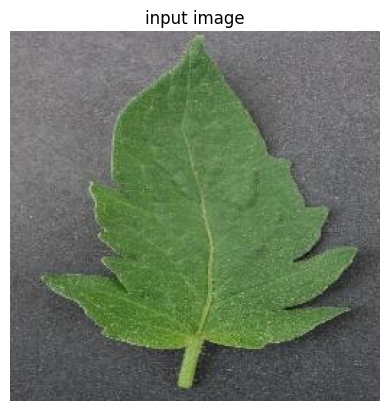

In [8]:
# load input image
image_path = "/content/drive/MyDrive/INTERNSHIP/img.jpg"

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.title("input image")
plt.axis("off")
plt.show()

In [9]:
# perform prediction
input_tensor = inference_transforms(image)
input_tensor = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)

    confidence, predicted_class = torch.max(probabilities, 1)

predicted_label = class_names[predicted_class.item()]
confidence_score = confidence.item() * 100

print(f"predicted disease: {predicted_label}")
print(f"confidence score: {confidence_score:.2f}%")

predicted disease: Tomato___healthy
confidence score: 99.99%


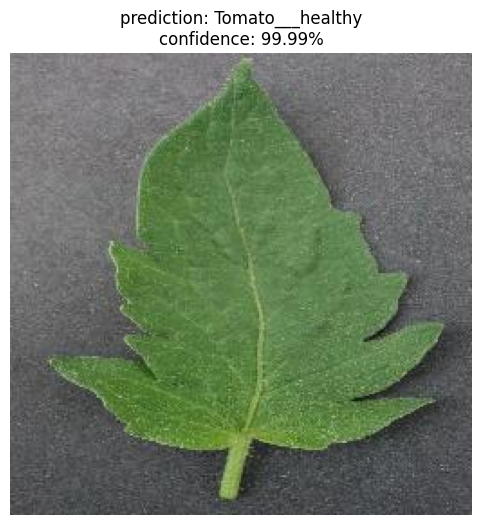

In [10]:
# display prediction
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(
    f"prediction: {predicted_label}\n"
    f"confidence: {confidence_score:.2f}%"
)
plt.axis("off")
plt.show()

In [11]:
# show top 3 predictions
top3_prob, top3_indices = torch.topk(probabilities, 3)

print("\ntop 3 predictions:")
for i in range(3):
    label = class_names[top3_indices[0][i]]
    prob  = top3_prob[0][i].item() * 100
    print(f"{i+1}. {label} — {prob:.2f}%")


top 3 predictions:
1. Tomato___healthy — 99.99%
2. Apple___Apple_scab — 0.01%
3. Squash___Powdery_mildew — 0.00%
